# Ramanujan's Dreams — System Overview

A bird's-eye, **runnable** tour of the system: the pipeline, the objects that
flow through it, how it is configured, and where the results land.

> This notebook is generated by
> [`data_utils/generate_system_overview_notebook.py`](./data_utils/generate_system_overview_notebook.py).
> Re-run that script after code changes to refresh it — do not edit the
> notebook by hand.

**What the system does, in one sentence:** given a mathematical *constant*, it
builds families of matrix recurrences (*CMFs*), carves each into cells
(*shards*), and searches the directions (*trajectories*) inside them for ones
that converge to the constant — recording an irrationality measure **δ** for
each.

## 0 — Setup

Running on Colab? Install the package first (uncomment below). Locally, just
make sure the `rama` environment is active.

In [ ]:
# On Colab, install the package (and its deps) from your checkout or git:
!pip install git+https://github.com/RamanujanMachine/Ramanujans-Dreams.git

In [2]:
%matplotlib inline
import sympy as sp
import mpmath as mp
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

mp.mp.dps = 60  # decimal places for high-precision display

## 1 — The five-stage pipeline

The system is a modular pipeline. Each stage consumes the previous stage's
output and is *substitutable* — you wire concrete modules into `System(...)`
and any class conforming to that stage's scheme can replace the default.

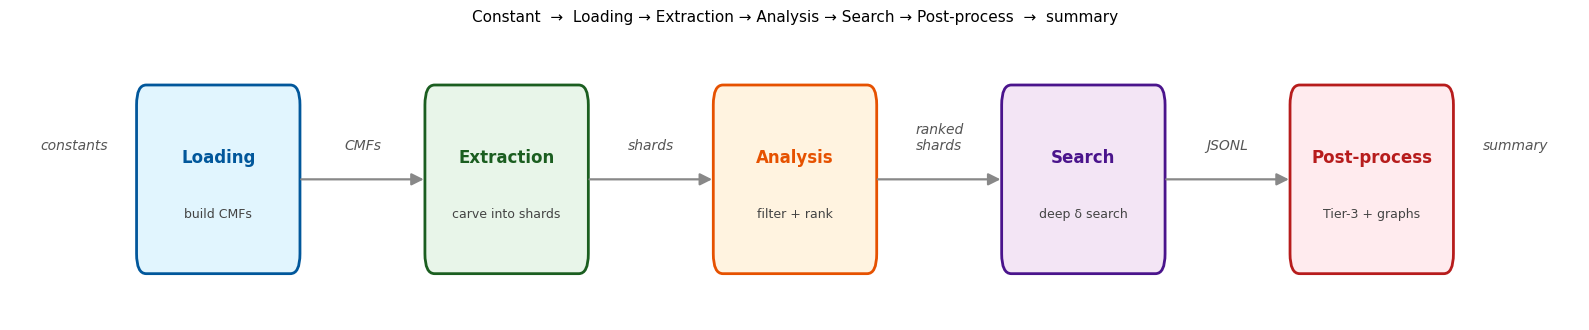

In [3]:
# A clean, offline diagram of the pipeline (matplotlib — no external service).
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stages = [
    ("Loading",      "build CMFs",        "#e1f5fe", "#01579b"),
    ("Extraction",   "carve into shards", "#e8f5e9", "#1b5e20"),
    ("Analysis",     "filter + rank",     "#fff3e0", "#e65100"),
    ("Search",       "deep δ search",     "#f3e5f5", "#4a148c"),
    ("Post-process", "Tier-3 + graphs",   "#ffebee", "#b71c1c"),
]
flows = ["constants", "CMFs", "shards", "ranked\nshards", "JSONL", "summary"]

fig, ax = plt.subplots(figsize=(16, 3.4))
n = len(stages)
box_w, box_h, gap = 2.0, 1.1, 1.6      # wider gap => longer arrows
label_y = box_h / 2 + 0.16             # flow labels sit ABOVE the arrows
for i, (name, sub, fill, edge) in enumerate(stages):
    x = i * (box_w + gap)
    ax.add_patch(FancyBboxPatch((x, 0), box_w, box_h,
                 boxstyle="round,pad=0.02,rounding_size=0.12",
                 linewidth=2, edgecolor=edge, facecolor=fill))
    ax.text(x + box_w / 2, 0.68, name, ha="center", va="center",
            fontsize=12, fontweight="bold", color=edge)
    ax.text(x + box_w / 2, 0.34, sub, ha="center", va="center",
            fontsize=9, color="#444")
    # data flowing INTO this stage — placed above the arrow, not on it
    ax.text(x - gap / 2, label_y, flows[i], ha="center", va="bottom",
            fontsize=10, style="italic", color="#555")
    if i < n - 1:
        ax.add_patch(FancyArrowPatch((x + box_w, box_h / 2),
                     (x + box_w + gap, box_h / 2),
                     arrowstyle="-|>", mutation_scale=18, color="#888", lw=1.6))
# data flowing OUT of the last stage
ax.text(n * (box_w + gap) - gap / 2, label_y, flows[-1],
        ha="center", va="bottom", fontsize=10, style="italic", color="#555")

ax.set_xlim(-gap, n * (box_w + gap))
ax.set_ylim(-0.3, box_h + 0.3)
ax.axis("off")
ax.set_title("Constant  →  Loading → Extraction → Analysis → Search → Post-process  →  summary",
             fontsize=11, pad=12)
plt.tight_layout()
plt.show()

| Stage | Default module | What it does | Output |
|:------|:---------------|:-------------|:-------|
| **Loading** | formatters / DB modules | Turn each constant into CMFs to search. | `Dict[Constant, List[CMFData]]` |
| **Extraction** | `ShardExtractorMod` | Slice each CMF's lattice into convex cells (**shards**). | `Dict[Constant, List[Shard]]` |
| **Analysis** | `AnalyzerModV1` | Cheap triage: keep shards that produce the constant, rank by best δ. | ranked `Dict[Constant, List[Shard]]` |
| **Search** | `SearcherModV1` (+ 5 optimisers) | Search each shard deeply for high-δ trajectories. | per-shard **JSONL** records |
| **Post-process** *(optional)* | `Tier3PostProcessModV1` | Expensive Tier-3 attributes + graphs. | JSONL patches + figures |

Each stage has its own README in `dreamer/<stage>/` with the details; the
repository `README.md` and `CONTRIBUTING.md` tie them together.

## 2 — Core objects

Four objects flow through the pipeline:

| Object | What it is |
|:-------|:-----------|
| **Constant** | the target value to find formulas for (π, ln 2, ζ(3), …) |
| **CMF** | a Conservative Matrix Field — a family of matrix recurrences, built by a *formatter* |
| **Shard** | a bounded convex cell of a CMF's integer lattice, `A·x < b`, with an interior point |
| **Trajectory** | an integer direction inside a shard; walking it gives a candidate formula + its δ |

### 2.1 Constants

In [3]:
from dreamer.utils.constants.constant import Constant
from dreamer import e, pi, euler_gamma, pi_squared, catalan, gompertz, zeta, log, sqrt

# Creating a dynamic constant registers it; re-creating returns the same one.
ln2, z3, root2 = log(2), zeta(3), sqrt(2)

rows = ["| Constant | sympy value | numeric (40 dp) |", "|:--|:--|:--|"]
for c in [pi, e, euler_gamma, catalan, ln2, z3, root2]:
    rows.append(f"| `{c.name}` | `{c.value_sympy}` | {mp.nstr(mp.mpf(sp.N(c.value_sympy, 45)), 40)} |")
display(Markdown("\n".join(rows)))

| Constant | sympy value | numeric (40 dp) |
|:--|:--|:--|
| `pi` | `pi` | 3.141592653589793238462643383279502884197 |
| `e` | `E` | 2.718281828459045235360287471352662497757 |
| `euler_gamma` | `EulerGamma` | 0.5772156649015328606065120900824024310422 |
| `catalan` | `Catalan` | 0.9159655941772190150546035149323841107741 |
| `log-2` | `log(2)` | 0.6931471805599453094172321214581765680755 |
| `zeta-3` | `zeta(3)` | 1.202056903159594285399738161511449990765 |
| `sqrt(2)` | `sqrt(2)` | 1.41421356237309504880168872420969807857 |

### 2.2 CMFs and formatters

You never write a CMF matrix by hand. You name an **inspiration function** and
a **formatter** builds the corresponding `ramanujantools` CMF:

| Formatter | File | Inspiration function | Example |
|:----------|:-----|:---------------------|:--------|
| `pFq` | `dreamer/loading/funcs/pFq_fmt.py` | hypergeometric ${}_pF_q$ | `pFq(log(2), 2, 1, -1)` → ${}_2F_1(z=-1)$ |
| `MeijerG` | `dreamer/loading/funcs/meijerG_fmt.py` | Meijer-G | `MeijerG(e, 1, 1, 1, 2, 1)` |
| `BaseCMF` | `dreamer/loading/funcs/base_cmf.py` | any hand-built CMF | wrap a raw `CMF` object |

A formatter also serialises to/from JSON — that is what lets the pipeline
export CMFs and reload them later (no pickles). The **shift** offsets the
lattice start point and must be an exact integer or `sp.Rational`.

In [4]:
# Build the 2F1(z=-1) CMF behind pFq(log(2), 2, 1, -1) and inspect it.
from dreamer.loading.funcs.pFq_fmt import pFq
from dreamer import log
from IPython.display import Math

fmt = pFq(log(2), 2, 1, -1)          # formatter: 2F1 with z = -1, for ln(2)
shift_cmf = fmt.to_cmf()             # -> a CMF + its shift
cmf = shift_cmf.cmf

print(f"cmf_name : {fmt.cmf_name}")
print(f"dimension: {cmf.dim()}  (= p + q = 2 + 1)")
print(f"symbols  : {list(cmf.matrices.keys())}")
print(f"shift    : {shift_cmf.shift}")
for sym, mat in cmf.matrices.items():
    display(Math(f"M_{{{sp.latex(sym)}}} = {sp.latex(mat)}"))

cmf_name : pFq_2_1_-1__0_0_0
dimension: 3  (= p + q = 2 + 1)
symbols  : [x0, x1, y0]
shift    : Position({x0: 0, x1: 0, y0: 0})


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### 2.3 Shards and trajectories

A CMF's matrices have **singular hyperplanes** (where entries blow up). They
carve the integer lattice into convex cells — the **shards**, each described
by a system `A·x < b` plus a guaranteed interior point. Inside one shard every
direction behaves consistently.

A **trajectory** is an integer direction that stays inside the shard forever (a
recession direction). Walking the product of the CMF matrices along it yields a
continued-fraction-like recurrence whose convergence to the constant is scored
by **δ**. Samplers (`pt`, `discrete`, `raycast`) draw trajectories inside the
shard's recession cone.

The plot below shows the idea in 3D. The seven planes
`x=0, y=0, z=0, x−z=0, x−z=1, y−z=0, y−z=1` partition the lattice into cells;
the **interior point (3, 3, 1)** sits inside one such cell (the shard), and the
arrow is the **trajectory direction (1, 1, 1)** — note it keeps `x−z` and `y−z`
fixed while climbing in `z`, so the ray stays inside the shard as it scales.

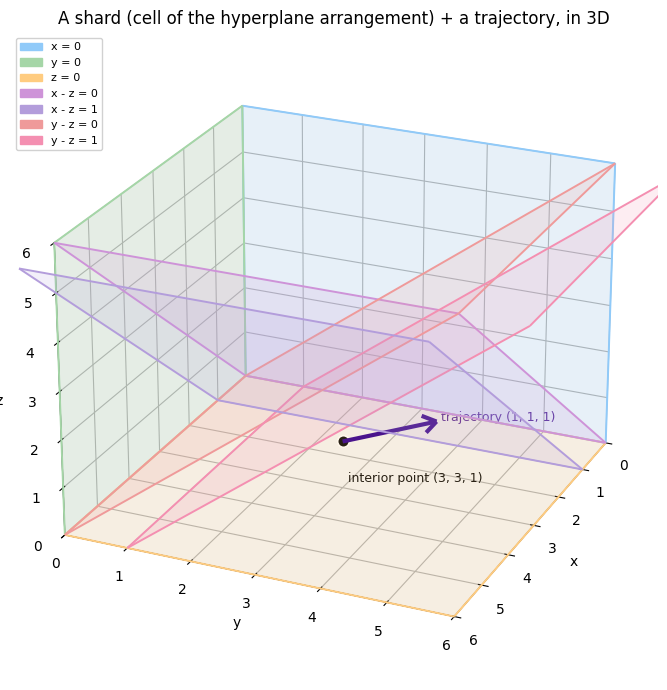

In [19]:
# The shard containing (3, 3, 1) as a cell of a 3D hyperplane arrangement,
# with the trajectory direction (1, 1, 1). (Illustrative geometry.)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers the 3d projection

LO, HI = 0.0, 6.0
g = np.linspace(LO, HI, 2)        # 2x2 grid is enough to draw a flat plane
u, v = np.meshgrid(g, g)
O = np.zeros_like(u)

# (label, colour, (X, Y, Z)) for each hyperplane, parametrised over (u, v).
planes = [
    ("x = 0",     "#90caf9", (O, u, v)),        # x = 0,           (y,z) = (u,v)
    ("y = 0",     "#a5d6a7", (u, O, v)),        # y = 0,           (x,z) = (u,v)
    ("z = 0",     "#ffcc80", (u, v, O)),        # z = 0,           (x,y) = (u,v)
    ("x - z = 0", "#ce93d8", (v, u, v)),        # x = z,           (y,z) = (u,v)
    ("x - z = 1", "#b39ddb", (v + 1, u, v)),    # x = z + 1,       (y,z) = (u,v)
    ("y - z = 0", "#ef9a9a", (u, v, v)),        # y = z,           (x,z) = (u,v)
    ("y - z = 1", "#f48fb1", (u, v + 1, v)),    # y = z + 1,       (x,z) = (u,v)
]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")
for _label, color, (X, Y, Z) in planes:
    # light fill + a crisp outline of each plane quad (2x2 grid => 4 edges).
    ax.plot_surface(X, Y, Z, color=color, alpha=0.16, linewidth=0, shade=False)
    ax.plot_wireframe(X, Y, Z, color=color, linewidth=1.4)

# interior point and the trajectory ray from it
p = np.array([3.0, 3.0, 1.0])
d = np.array([1.0, 1.0, 1.0])
ax.scatter(*p, color="black", s=70, depthshade=False,
           edgecolors="white", linewidths=1.2, zorder=10)
ax.text(p[0] + 0.15, p[1] + 0.15, p[2] - 0.75, "interior point (3, 3, 1)",
        color="black", fontsize=9)
ax.quiver(*p, *(2.5 * d), color="#4a148c", lw=3, arrow_length_ratio=0.13)
ax.text(*(p + 2.6 * d), "trajectory (1, 1, 1)", color="#4a148c", fontsize=9)

ax.set_xlim(LO, HI); ax.set_ylim(LO, HI); ax.set_zlim(LO, HI)
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")
ax.set_title("A shard (cell of the hyperplane arrangement) + a trajectory, in 3D")
ax.view_init(elev=24, azim=24)
ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c, _ in planes],
          loc="upper left", fontsize=8, framealpha=0.9)
plt.tight_layout(); plt.show()

## 3 — Configuration

Every tunable lives in a config **category** reached through one global
manager. Change settings with `config.configure(...)`, and list any category's
fields (with descriptions) using `config.<category>.display()`.

| Category | Drives |
|:---------|:-------|
| `config.system` | paths, export directories, core/worker budget |
| `config.extraction` | shard-extraction strategy + trajectory sampling |
| `config.analysis` | shard filtering / prioritisation |
| `config.search` | deep search + Tier-2 attributes (largest category) |
| `config.post_process` / `config.graph` | Tier-3 attributes / graphing |
| `config.database` / `config.logging` | DB mode / logging + watchdogs |

See `dreamer/configs/README.md` for the full, annotated list.

In [6]:
from dreamer import config

# A few knobs you are most likely to touch:
print("extraction.STRATEGY        :", config.extraction.STRATEGY)
print("analysis.SAMPLING_METHOD   :", config.analysis.SAMPLING_METHOD)
print("analysis.IDENTIFY_THRESHOLD:", config.analysis.IDENTIFY_THRESHOLD)
print("search.SAMPLING_METHOD     :", config.search.SAMPLING_METHOD)
print("search.GLOBAL_SEED         :", config.search.GLOBAL_SEED)
print("search.TIER2_ATTRIBUTES    :", len(config.search.TIER2_ATTRIBUTES), "attributes")

# Change settings (any number of categories / fields at once):
config.configure(
    analysis={"IDENTIFY_THRESHOLD": 1e-3},
    search={"MAX_TRAJECTORY_LENGTH": 15},
)
print("\nafter configure -> analysis.IDENTIFY_THRESHOLD =", config.analysis.IDENTIFY_THRESHOLD)

extraction.STRATEGY        : auto
analysis.SAMPLING_METHOD   : pt
analysis.IDENTIFY_THRESHOLD: -1
search.SAMPLING_METHOD     : pt
search.GLOBAL_SEED         : 42
search.TIER2_ATTRIBUTES    : 10 attributes

after configure -> analysis.IDENTIFY_THRESHOLD = 0.001


## 4 — Where results live: per-shard JSONL

There is **one canonical store**: one JSON-lines file per shard,
`<EXPORT_SEARCH_RESULTS>/<shard_id>.jsonl`, with **one trajectory per line**
(no pickles). Analysis and search write to the same store, so search re-uses
analysis's records and nothing is walked twice; the run summary and best-δ
reporting read it back.

Each line is a `TrajectoryDTO`: cheap **Tier-1** fields (δ, identified, limit,
recurrence, p/q) are always present, and any configured **Tier-2** attributes
land in an open `extended_metrics` dict.

In [7]:
# The fields stored on every trajectory record.
import dataclasses
from dreamer.utils.storage.dtos import TrajectoryDTO

try:
    names = [f.name for f in dataclasses.fields(TrajectoryDTO)]
except TypeError:
    names = [a for a in vars(TrajectoryDTO).get("__annotations__", {})]
print("TrajectoryDTO fields:")
for nm in names:
    print("  -", nm)

TrajectoryDTO fields:
  - trajectory_id
  - cmf_id
  - shard_id
  - start_point
  - direction
  - delta_estimate
  - p_vector
  - q_vector
  - identified
  - walk_type
  - walk_depth
  - config_fingerprint
  - projection_column
  - recurrence_relation
  - recurrence_order
  - extended_metrics


## 5 — Optional: a tiny end-to-end run

This runs the whole pipeline on a small CMF into a temporary directory, then
reads back one stored trajectory record. It is the most faithful demo, but it
walks real trajectories and uses LIReC, so it can take a minute. Skip it if you
just want the tour.

In [21]:
RUN_LIVE = True  # set True to actually run the pipeline

if RUN_LIVE:
    import os, glob, json, tempfile
    from dreamer import System, config, analysis, search, extraction, post_process
    from dreamer.loading import pFq
    from dreamer import log

    workdir = tempfile.mkdtemp(prefix="rama_overview_")
    config.configure(
        system={"EXPORT_CMFS": os.path.join(workdir, "cmfs"),
                "EXPORT_SEARCH_RESULTS": os.path.join(workdir, "results")},
        extraction={"STRATEGY": "heuristic", "HEURISTIC_TIMEOUT_SECONDS": 60.0, 
                    "IGNORE_DUPLICATE_SEARCHABLES": True},
        analysis={"IDENTIFY_THRESHOLD": 1e-3,
                  "NUM_TRAJECTORIES_FROM_DIM": (lambda d: max(10 ** (d - 1), 10))},
        search={"NUM_TRAJECTORIES_FROM_DIM": (lambda d: max(10 ** d, 10)),
                "TIER2_ATTRIBUTES": ()},
    )

    System(
        function_sources=[pFq(log(2), 2, 1, -1)],
        extractor=extraction.extractor.ShardExtractorMod,
        analyzers=[analysis.AnalyzerModV1],
        searcher=search.SearcherModV1,
    ).run(constants=[log(2)])

    files = glob.glob(os.path.join(workdir, "results", "*.jsonl"))
    print(f"wrote {len(files)} per-shard JSONL file(s) under {workdir}")
    if files:
        with open(files[0]) as fh:
            rec = json.loads(fh.readline())
        print("first trajectory record (keys):", sorted(rec.keys()))
        print("delta_estimate:", rec.get("delta_estimate"))
else:
    print("RUN_LIVE is False — set it to True to execute the pipeline.")

[INFO] Loading CMFs ...
[INFO] CMFs for log-2 exported to /tmp/rama_overview_1hdee0zu/cmfs/log-2
[INFO] Searching for log-2 using inspiration functions: 
1. CMF: pFq((2, 1, -1)) with offset (0, 0, 0)



Extracting shards                                                              | 00:03 ?it/s (0.00%)

[INFO] In CMF no. 1: found 7 hyperplanes and 12 shards 



Creating shard objects                                                         | 00:00 ?it/s (0.00%)
Extracting shards                            ███████████████████████████ | 00:03  3.29s/it (100.00%)
Analyzing constants and their CMFs                                             | 00:00 ?it/s (0.00%)

================================================================ Analyzing for log-2 =================================================================


...

[INFO] Shard pFq_2_1_-1__0_0_0__9e4b0a98e1dfee30 — start point (-4, -1, -2); identified trajectories: log-2 0.00% (0/5)
[INFO] Shard 11 in pFq_2_1_-1__0_0_0 - searching log-2:                   [identified: ❌]



  Shard pFq_2_1_… trajectories                                                 | 00:00 ?it/s (0.00%)
  Shard pFq_2_1_… trajectories               █████▌                       | 00:00  1.96it/s (20.00%)
  Shard pFq_2_1_… trajectories               ███████████▏                 | 00:00  2.79it/s (40.00%)
  Shard pFq_2_1_… trajectories               ████████████████▊            | 00:00  4.06it/s (60.00%)
  Shard pFq_2_1_… trajectories               ██████████████████████▍      | 00:01  4.68it/s (80.00%)
  Shard pFq_2_1_… trajectories               ███████████████████████████ | 00:01  2.86it/s (100.00%)


[INFO] Shard pFq_2_1_-1__0_0_0__fdccb5c0b6ccb64d — start point (1, 4, 3); identified trajectories: log-2 0.00% (0/5)
[INFO] Shard 12 in pFq_2_1_-1__0_0_0 - searching log-2:                   [identified: ❌]


Searching in shards:                                                           | 00:00 ?it/s (0.00%)
  Shard pFq_2_1_… trajectories                                                 | 00:00 ?it/s (0.00%)
  Shard pFq_2_1_… trajectories               █▍                            | 00:00  3.70it/s (4.76%)
  Shard pFq_2_1_… trajectories               ██                            | 00:00  3.22it/s (7.14%)
  Shard pFq_2_1_… trajectories               ██▊                           | 00:01  2.44it/s (9.52%)
  Shard pFq_2_1_… trajectories               ███▎                         | 00:01  2.29it/s (11.90%)
  Shard pFq_2_1_… trajectories               ████                         | 00:02  2.44it/s (14.29%)
  Shard pFq_2_1_… trajectories               ████▋                        | 00:02  2.43it/s (16.67%)
  Shard pFq_2_1_… trajectories               █████▎                       | 00:03  2.48it/s (19.05%)
  Shard pFq_2_1_… trajectories               ██████                       | 00:03  2.60it/s

[INFO] Best delta for "log-2" is 0.342917
* Trajectory id: pFq_2_1_-1__0_0_0__62404e5f3784b027__26a5ed04a5b467e6
* Start:         (-1, 2, 1)
* Direction:     (-5, 5, 1)
[WARNING] Failed to derive shard id for summary filter: cannot access local variable 'derive_cmf_and_shard_ids' where it is not associated with a value
[WARNING] Failed to derive shard id for summary filter: cannot access local variable 'derive_cmf_and_shard_ids' where it is not associated with a value
[WARNING] Failed to derive shard id for summary filter: cannot access local variable 'derive_cmf_and_shard_ids' where it is not associated with a value
[WARNING] Failed to derive shard id for summary filter: cannot access local variable 'derive_cmf_and_shard_ids' where it is not associated with a value
[WARNING] Failed to derive shard id for summary filter: cannot access local variable 'derive_cmf_and_shard_ids' where it is not associated with a value
[WARNING] Failed to derive shard id for summary filter: cannot access l

## 6 — Sanity tests

Self-contained checks that the install is consistent and the core abstractions
behave. Run them top-to-bottom; each prints PASS/FAIL on its own.

In [9]:
# Test 1 — Constant registry
print("Test 1: Constant registry")
try:
    from dreamer.utils.constants.constant import Constant
    from dreamer import zeta, log, sqrt

    for name in ["e", "pi", "euler_gamma", "pi_squared", "catalan", "gompertz"]:
        assert Constant.is_registered(name), f"{name} not registered"

    z3 = zeta(3);  assert Constant.is_registered("zeta-3")
    ln2 = log(2);  assert Constant.is_registered("log-2")
    assert zeta(3).name == z3.name, "zeta(3) re-creation inconsistent"

    print(f"  PASS — {len(Constant.available_constants())} constants registered")
except Exception as exc:
    print(f"  FAIL — {exc}")

Test 1: Constant registry
  PASS — 10 constants registered


In [10]:
# Test 2 — High-precision constant values
print("Test 2: High-precision values")
mp.mp.dps = 60
REFERENCE = {
    "e":     (sp.E,        "2.718281828459045235360287"),
    "pi":    (sp.pi,       "3.141592653589793238462643"),
    "log-2": (sp.log(2),   "0.693147180559945309417232"),
    "zeta-3":(sp.zeta(3),  "1.202056903159594285399738"),
}
ok = True
for name, (expr, prefix) in REFERENCE.items():
    val = mp.nstr(mp.mpf(sp.N(expr, 55)), 26)
    match = val.startswith(prefix[:18])
    ok &= match
    print(f"  {'ok' if match else 'XX'} {name:8s} = {val}")
print(f"  {'PASS' if ok else 'FAIL'}")

Test 2: High-precision values
  ok e        = 2.7182818284590452353602875
  ok pi       = 3.1415926535897932384626434
  ok log-2    = 0.69314718055994530941723212
  ok zeta-3   = 1.2020569031595942853997382
  PASS


In [11]:
# Test 3 — Formatter registry
print("Test 3: Formatter registry")
try:
    from dreamer.loading.funcs.formatter import Formatter
    from dreamer.loading.funcs.pFq_fmt import pFq          # noqa: F401
    from dreamer.loading.funcs.meijerG_fmt import MeijerG  # noqa: F401
    from dreamer.loading.funcs.base_cmf import BaseCMF     # noqa: F401

    expected = {"pFq", "MeijerG", "BaseCMF"}
    registered = set(Formatter.registry.keys())
    assert expected.issubset(registered), f"missing: {expected - registered}"
    print(f"  PASS — registered: {sorted(registered)}")
except Exception as exc:
    print(f"  FAIL — {exc}")

Test 3: Formatter registry
  PASS — registered: ['BaseCMF', 'MeijerG', 'pFq']


In [12]:
# Test 4 — pFq formatter JSON round-trip (the no-pickle reload contract)
print("Test 4: pFq JSON round-trip")
try:
    from dreamer.loading.funcs.pFq_fmt import pFq
    from dreamer.loading.funcs.formatter import Formatter
    from dreamer import log

    original = pFq(log(2), 2, 1, -1)
    restored = Formatter.from_json_obj(original.to_json_obj())
    assert isinstance(restored, pFq)
    assert restored.p == 2 and restored.q == 1
    assert restored.cmf_name == original.cmf_name
    print(f"  PASS — round-tripped {original.cmf_name}")
except Exception as exc:
    print(f"  FAIL — {exc}")

Test 4: pFq JSON round-trip
  PASS — round-tripped pFq_2_1_-1__0_0_0


In [13]:
# Test 5 — CMF construction + dimension
print("Test 5: CMF construction")
try:
    from dreamer.loading.funcs.pFq_fmt import pFq
    from dreamer import log

    cmf = pFq(log(2), 2, 1, -1).to_cmf().cmf
    assert cmf.dim() == 3, f"expected dim 3, got {cmf.dim()}"
    assert len(cmf.matrices) == 3
    print(f"  PASS — 2F1(z=-1): dim={cmf.dim()}, symbols={list(cmf.matrices.keys())}")
except Exception as exc:
    print(f"  FAIL — {exc}")

Test 5: CMF construction
  PASS — 2F1(z=-1): dim=3, symbols=[x0, x1, y0]


In [14]:
# Test 6 — Trajectory-count config returns positive values
print("Test 6: Trajectory configuration")
try:
    from dreamer import config
    for d in range(1, 5):
        na = config.analysis.NUM_TRAJECTORIES_FROM_DIM(d)
        ns = config.search.NUM_TRAJECTORIES_FROM_DIM(d)
        assert na > 0 and ns > 0
        print(f"  dim={d}: analysis={na:>8,}  search={ns:>8,}")
    print("  PASS")
except Exception as exc:
    print(f"  FAIL — {exc}")

Test 6: Trajectory configuration
  dim=1: analysis=      10  search=      10
  dim=2: analysis=     100  search=     100
  dim=3: analysis=   1,000  search=   1,000
  dim=4: analysis=  10,000  search=  10,000
  PASS


In [15]:
# Test 7 — Database insert / select round-trip (temp file)
print("Test 7: Database round-trip")
try:
    import os, tempfile
    from dreamer.loading.databases.db_v1.db import DB
    from dreamer.loading.funcs.pFq_fmt import pFq
    from dreamer import log

    with tempfile.TemporaryDirectory() as tmp:
        db = DB(path=os.path.join(tmp, "test.db"))
        db.insert(log(2), [pFq(log(2), 2, 1, -1)])
        retrieved = db.select(log(2))
        assert len(retrieved) == 1, f"expected 1 CMF, got {len(retrieved)}"
    print("  PASS — stored and retrieved 1 CMF for log(2)")
except Exception as exc:
    print(f"  FAIL — {exc}")

Test 7: Database round-trip


  PASS — stored and retrieved 1 CMF for log(2)


---
## Summary

| # | Test | Verifies |
|:--|:-----|:---------|
| 1 | Constant registry | static + dynamic constants register correctly |
| 2 | High-precision values | mpmath values match known digits |
| 3 | Formatter registry | `pFq`, `MeijerG`, `BaseCMF` all registered |
| 4 | pFq JSON round-trip | serialise → deserialise preserves the formatter |
| 5 | CMF construction | `pFq(log(2),2,1,-1)` is a 3-D CMF |
| 6 | Trajectory config | `NUM_TRAJECTORIES_FROM_DIM` returns positive counts |
| 7 | Database round-trip | SQLite insert → select preserves CMF data |

**Where to go next:** the repository `README.md` (usage), `CONTRIBUTING.md`
(how to add modules), the per-stage `dreamer/<stage>/README.md`, and
`dreamer/configs/README.md` (every configuration field).